In [1]:
import pickle
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/sietch_colab/akapoor/Infer_Demography/experiments"
MODELS = {
    "drosophila_three_epoch": f"{BASE}/drosophila_three_epoch_prior/real_data_analysis",
    "split_migration_growth": f"{BASE}/split_migration_growth/real_data_analysis",
}
SFS_ENGINES  = ["moments", "dadi"]
ALL_ENGINES  = ["moments", "dadi", "momentsld"]

def _unwrap(d):
    """Unwrap single-element lists stored in best_fit.pkl."""
    out = {}
    for k, v in d.items():
        out[k] = v[0] if isinstance(v, list) and len(v) == 1 else v
    return out

def load_best_sfs_run(base_root, engine):
    path = f"{base_root}/inferences/{engine}/best_fit.pkl"
    try:
        return _unwrap(pickle.load(open(path, "rb")))
    except FileNotFoundError:
        return None

def load_momentsld_result(base_root):
    path = f"{base_root}/inferences/MomentsLD/best_fit.pkl"
    try:
        d = _unwrap(pickle.load(open(path, "rb")))
        if "best_ll" not in d and "best_lls" in d:
            d["best_ll"] = float(d["best_lls"])
        return d
    except FileNotFoundError:
        return None

results = {}
for model, base_root in MODELS.items():
    for engine in SFS_ENGINES:
        d = load_best_sfs_run(base_root, engine)
        if d is not None:
            results[(model, engine)] = d
            print(f"{model} / {engine}: LL = {d['best_ll']:.4f}")
        else:
            print(f"{model} / {engine}: NOT FOUND")
    ld = load_momentsld_result(base_root)
    if ld is not None:
        results[(model, "momentsld")] = ld
        print(f"{model} / momentsld: LL = {ld['best_ll']:.4f}")
    else:
        print(f"{model} / momentsld: NOT FOUND")

drosophila_three_epoch / moments: LL = 4140610.9841
drosophila_three_epoch / dadi: LL = 4040744.9872
drosophila_three_epoch / momentsld: NOT FOUND
split_migration_growth / moments: LL = 4156401.1382
split_migration_growth / dadi: NOT FOUND
split_migration_growth / momentsld: LL = -47733832.1249


## 1. Moments vs dadi parameter comparison (within each model)

In [2]:
for model in MODELS:
    mom = results.get((model, "moments"))
    dad = results.get((model, "dadi"))
    if mom is None or dad is None:
        print(f"{model}: missing one or both engines, skipping")
        continue

    params = list(mom["best_params"].keys())
    rows = []
    for p in params:
        v_m = mom["best_params"].get(p, np.nan)
        v_d = dad["best_params"].get(p, np.nan)
        ratio = v_m / v_d if v_d != 0 else np.nan
        rows.append({"parameter": p, "moments": v_m, "dadi": v_d, "moments/dadi": ratio})

    df = pd.DataFrame(rows).set_index("parameter")
    print(f"\n=== {model} ===")
    print(f"  moments LL: {mom['best_ll']:.2f}   dadi LL: {dad['best_ll']:.2f}")
    display(df.style.format("{:.4g}").background_gradient(subset=["moments/dadi"], cmap="RdYlGn", vmin=0.5, vmax=2.0))


=== drosophila_three_epoch ===
  moments LL: 4140610.98   dadi LL: 4040744.99


,moments,dadi,moments/dadi
parameter,,,
N_ANC,4.397e+06,3.508e+06,1.254
N_AFR,9.162e+05,4.86e+05,1.885
N_EUR_bottleneck,3.227e+05,2.961e+06,0.109
N_EUR_recover,8.913e+05,3.508e+05,2.54
T_AFR_expansion,8.794e+06,2.716e+06,3.238
T_AFR_EUR_split,2.198e+05,4.15e+05,0.5297
T_EUR_expansion,1264,9923,0.1274


split_migration_growth: missing one or both engines, skipping


## 2. Parameter comparison plot

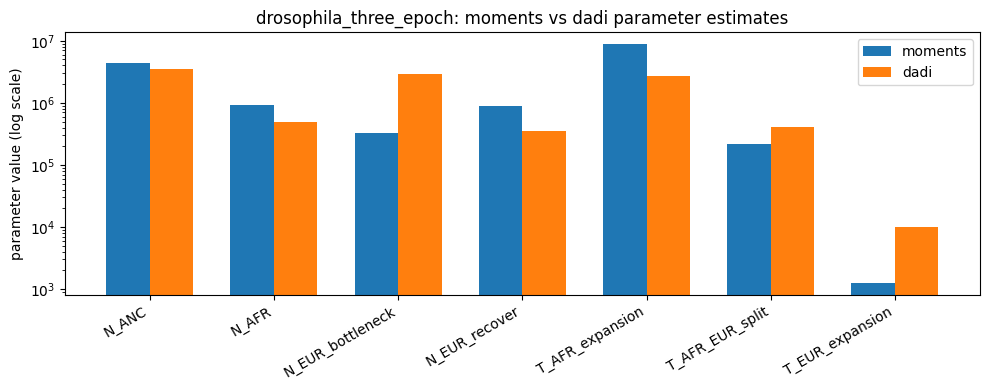

In [3]:
for model in MODELS:
    mom = results.get((model, "moments"))
    dad = results.get((model, "dadi"))
    if mom is None or dad is None:
        continue

    params = list(mom["best_params"].keys())
    v_m = np.array([mom["best_params"][p] for p in params])
    v_d = np.array([dad["best_params"][p] for p in params])

    x = np.arange(len(params))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - width/2, v_m, width, label="moments")
    ax.bar(x + width/2, v_d, width, label="dadi")
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=30, ha="right")
    ax.set_title(f"{model}: moments vs dadi parameter estimates")
    ax.set_ylabel("parameter value (log scale)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. AIC comparison — which model fits better per engine?

AIC = 2k − 2·LL, lower = better. Both models have 7 free parameters.  
ΔAIC > 10 = strong evidence; ΔAIC > 100 = overwhelming evidence.  
**Important**: MomentsLD uses a composite Gaussian likelihood, so its absolute LL values are not comparable to the SFS Poisson LL. ΔAIC is valid *within* each engine but not *across* engines.


In [4]:
K = 7  # both models have 7 free parameters

rows = []
for model in MODELS:
    for engine in ALL_ENGINES:
        d = results.get((model, engine))
        if d is None:
            continue
        ll  = d["best_ll"]
        aic = 2 * K - 2 * ll
        rows.append({"model": model, "engine": engine, "LL": ll, "AIC": aic})

aic_df = pd.DataFrame(rows).set_index(["model", "engine"])

# Per-engine ΔAIC
print("ΔAIC relative to best model within each engine:")
print("=" * 60)
for engine in ALL_ENGINES:
    sub = aic_df[aic_df.index.get_level_values("engine") == engine]["AIC"]
    if sub.empty:
        print(f"  {engine}: NOT FOUND")
        continue
    best = sub.min()
    print(f"\n  {engine}:")
    for (model, eng), aic_val in aic_df["AIC"].items():
        if eng != engine:
            continue
        delta = aic_val - best
        winner = " ← WINNER" if delta == 0 else f"   ΔAIC = {delta:.1f}"
        print(f"    {model}{winner}")

display(aic_df.style.format({"LL": "{:.2f}", "AIC": "{:.2f}"}))


ΔAIC relative to best model within each engine:

  moments:
    drosophila_three_epoch   ΔAIC = 31580.3
    split_migration_growth ← WINNER

  dadi:
    drosophila_three_epoch ← WINNER

  momentsld:
    split_migration_growth ← WINNER


## 4. Consensus: do all engines agree?


In [5]:
model_list = list(MODELS.keys())

votes = {}
for engine in ALL_ENGINES:
    lls = {}
    for model in model_list:
        d = results.get((model, engine))
        if d is not None:
            lls[model] = d["best_ll"]
    if len(lls) == 2:
        winner = max(lls, key=lls.get)
        loser  = [m for m in model_list if m != winner][0]
        delta_ll = lls[winner] - lls[loser]
        delta_aic = 2 * delta_ll  # ΔAIC = -2ΔLL; lower AIC = higher LL
        votes[engine] = {"winner": winner, "delta_aic": delta_aic}
        print(f"  {engine:12s}  winner={winner}  ΔAIC={delta_aic:.1f}")
    else:
        print(f"  {engine:12s}  insufficient data")

all_winners = [v["winner"] for v in votes.values()]
if len(set(all_winners)) == 1:
    print(f"\n✓ All engines agree: {all_winners[0]} is the better-fitting model.")
else:
    print(f"\n✗ Engines disagree: {dict(zip(ALL_ENGINES, all_winners))}")


  moments       winner=split_migration_growth  ΔAIC=31580.3
  dadi          insufficient data
  momentsld     insufficient data

✓ All engines agree: split_migration_growth is the better-fitting model.


## 5. Profile log-likelihood curves — convergence diagnostic

Each subplot is one parameter. Lines are individual optimization runs (different random starts).  
A **well-converged run** shows a clear inverted-U with its peak well away from the bounds.  
Red flags: flat curve (unidentifiable), peak hugging a boundary, runs peaking at very different x locations (multiple local optima).

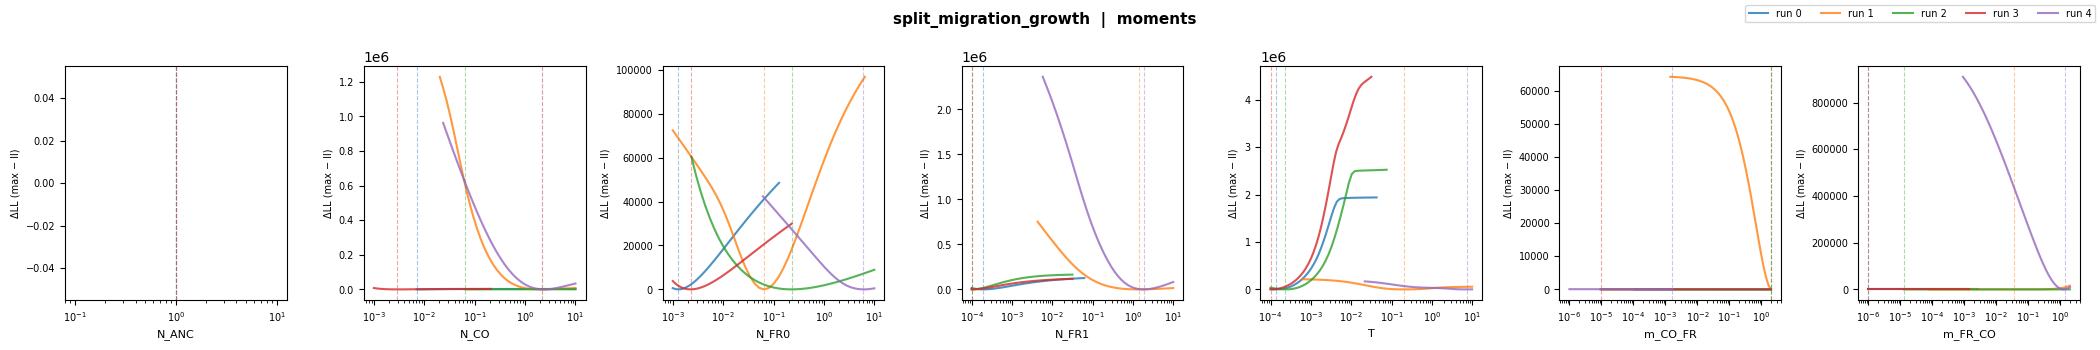

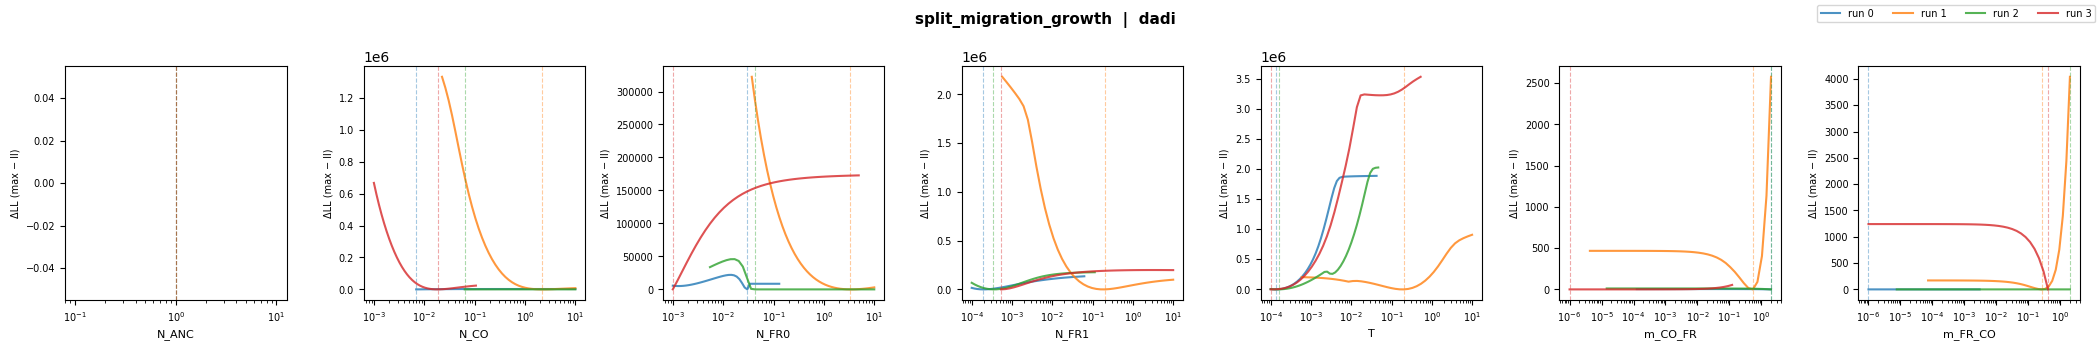

In [6]:
BASE = "/sietch_colab/akapoor/Infer_Demography/experiments"
PARAMS_BY_MODEL = {
    "drosophila_three_epoch": ["N_ANC", "N_AFR", "N_EUR_bottleneck", "N_EUR_recover",
                                "T_AFR_expansion", "T_AFR_EUR_split", "T_EUR_expansion"],
    "split_migration_growth": ["N_ANC", "N_CO", "N_FR0", "N_FR1", "T", "m_CO_FR", "m_FR_CO"],
}

for model in MODELS:
    params = PARAMS_BY_MODEL[model]
    for engine in SFS_ENGINES:
        runs_root = f"{BASE}/{model}/real_data_analysis/runs"
        run_dirs = sorted(glob.glob(f"{runs_root}/run_*"))
        if not run_dirs:
            continue

        fig, axes = plt.subplots(1, len(params), figsize=(3 * len(params), 3.5), sharey=False)
        fig.suptitle(f"{model}  |  {engine}", fontsize=11, fontweight="bold")
        colors = plt.cm.tab10.colors

        for ax, param in zip(axes, params):
            any_plotted = False
            for run_i, run_dir in enumerate(run_dirs):
                npz_path = f"{run_dir}/inferences/{engine}/likelihood_plots_scaled/profile_{param}.npz"
                npz_paths = glob.glob(npz_path)
                if not npz_paths:
                    continue
                d = np.load(npz_paths[0])
                grid_log10 = d["grid_log10"]
                ll = d["ll"]

                # normalise: ΔLL = ll_max - ll  (so optimum sits at 0, curve rises away)
                delta_ll = ll.max() - ll

                ax.plot(10**grid_log10, delta_ll,
                        color=colors[run_i % len(colors)],
                        alpha=0.8, lw=1.5,
                        label=f"run {run_i}")

                # mark the optimum
                opt_x = 10**grid_log10[np.argmin(delta_ll)]
                ax.axvline(opt_x, color=colors[run_i % len(colors)],
                           alpha=0.4, lw=0.8, linestyle="--")
                any_plotted = True

            ax.set_xscale("log")
            ax.set_xlabel(param, fontsize=8)
            ax.set_ylabel("ΔLL (max − ll)", fontsize=7)
            ax.tick_params(labelsize=7)
            if not any_plotted:
                ax.set_title("no data", fontsize=7)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=len(run_dirs))
        plt.tight_layout()
        plt.show()

## 6. MomentsLD profile log-likelihood curves

Parameters are in **absolute space**: N values in individuals, T in generations, m in per-generation rates.  
Each line is one optimisation run (different LHS start). A well-identified parameter shows a clear minimum well away from the bounds; boundary-hugging means unidentified.

In [ ]:
RUNS_ROOT_LD = {
    "drosophila_three_epoch": f"{BASE}/drosophila_three_epoch_prior/real_data_analysis/runs",
    "split_migration_growth": f"{BASE}/split_migration_growth/real_data_analysis/runs",
}

for model in MODELS:
    params = PARAMS_BY_MODEL[model]
    runs_root = RUNS_ROOT_LD[model]
    run_dirs = sorted(glob.glob(f"{runs_root}/run_*"))
    if not run_dirs:
        continue

    fig, axes = plt.subplots(1, len(params), figsize=(3 * len(params), 3.5), sharey=False)
    fig.suptitle(f"{model}  |  MomentsLD", fontsize=11, fontweight="bold")
    colors = plt.cm.tab10.colors

    for ax, param in zip(axes, params):
        any_plotted = False
        for run_i, run_dir in enumerate(run_dirs):
            npz_path = f"{run_dir}/inferences/MomentsLD/likelihood_plots_scaled/profile_{param}.npz"
            npz_paths = glob.glob(npz_path)
            if not npz_paths:
                continue
            d = np.load(npz_paths[0])
            grid_log10 = d["grid_log10"]
            ll = d["ll"]

            delta_ll = ll.max() - ll

            ax.plot(10**grid_log10, delta_ll,
                    color=colors[run_i % len(colors)],
                    alpha=0.8, lw=1.5,
                    label=f"run {run_i}")

            opt_x = 10**grid_log10[np.argmin(delta_ll)]
            ax.axvline(opt_x, color=colors[run_i % len(colors)],
                       alpha=0.4, lw=0.8, linestyle="--")
            any_plotted = True

        ax.set_xscale("log")
        ax.set_xlabel(param, fontsize=8)
        ax.set_ylabel("ΔLL (max − ll)", fontsize=7)
        ax.tick_params(labelsize=7)
        if not any_plotted:
            ax.set_title("no data", fontsize=7)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=7, ncol=len(run_dirs))
    plt.tight_layout()
    plt.show()


## 7. Optimizer landscape: where did each run land?

Extract the per-run MLE (argmax of profile LL) for every parameter and visualise as a **parallel coordinates plot**.  
Each line is one run; colour encodes that run's best LL (darker = higher LL = better basin).  
Runs that found the same basin overlap; outliers diverge.  
A bar chart below shows each run's best LL so you can see whether the basins are meaningfully different.

/tmp/ipykernel_4050534/4066049129.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("YlGn")


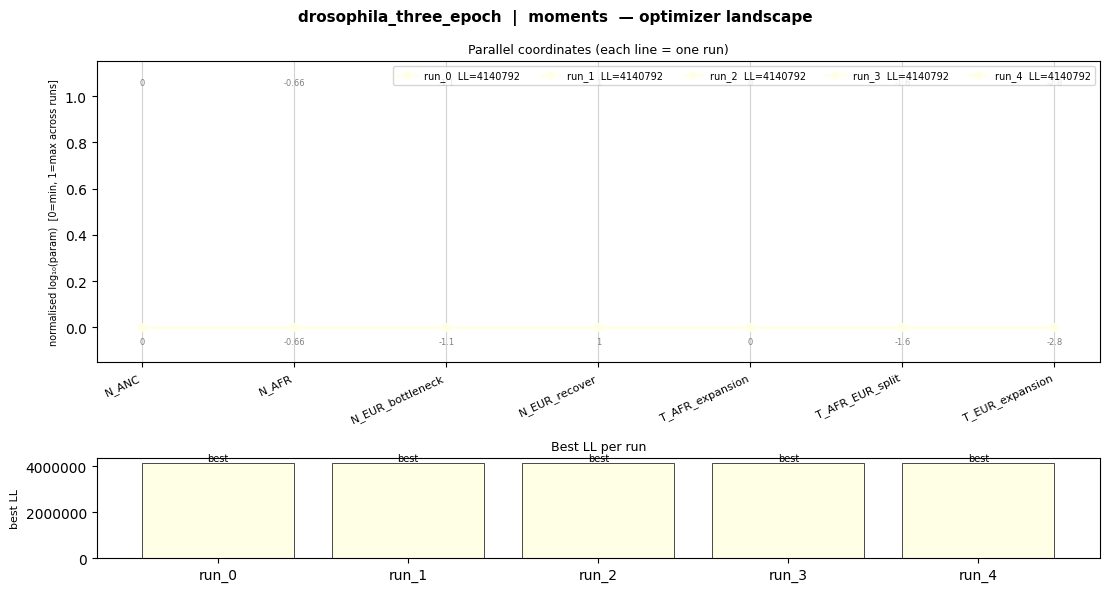

/tmp/ipykernel_4050534/4066049129.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("YlGn")


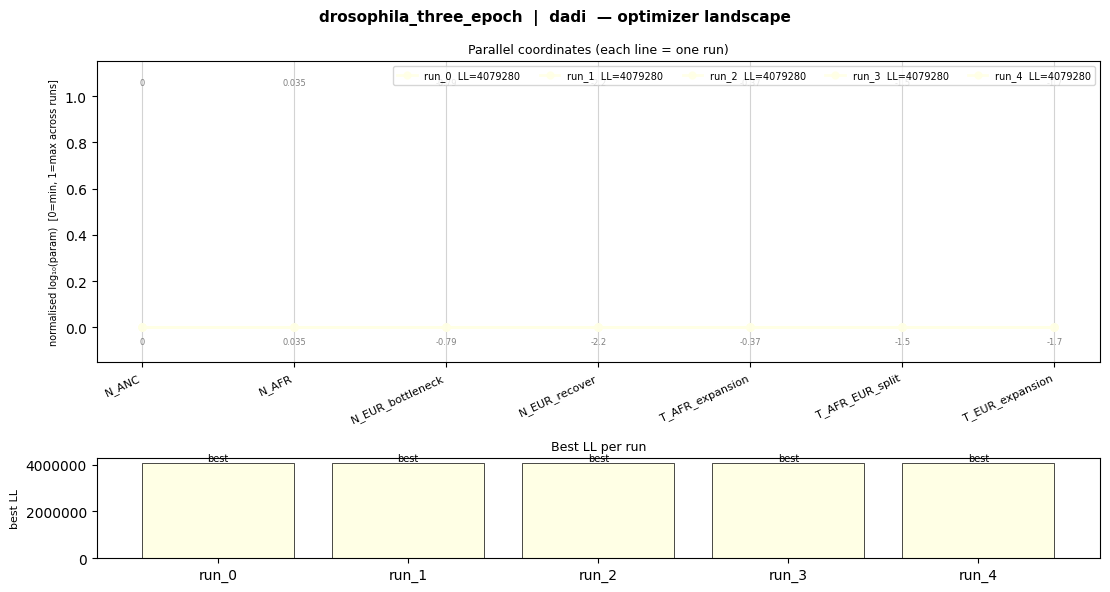

/tmp/ipykernel_4050534/4066049129.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("YlGn")


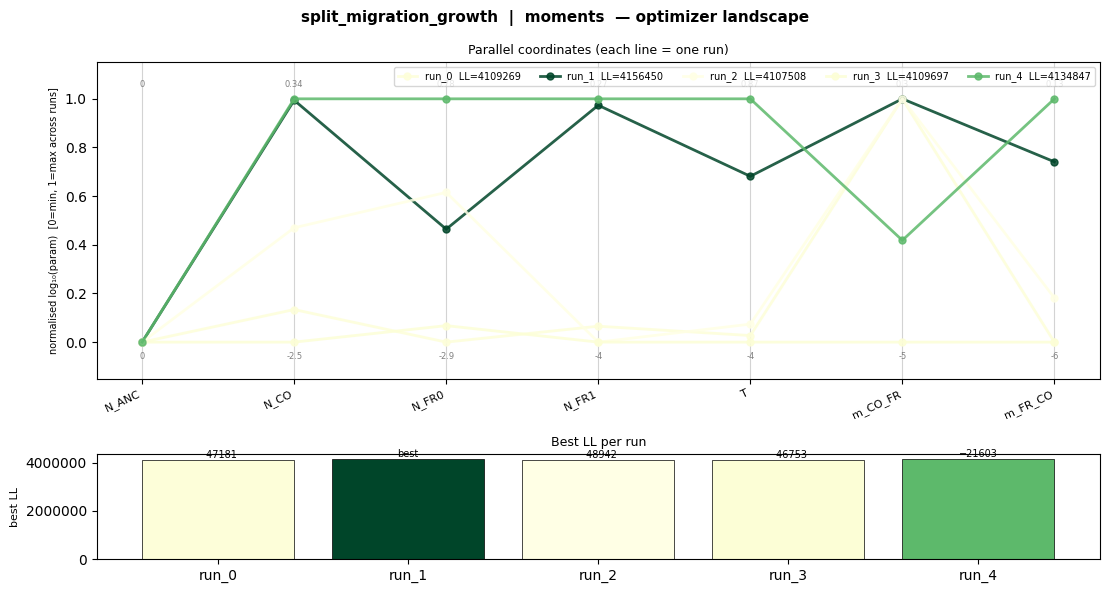

/tmp/ipykernel_4050534/4066049129.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("YlGn")


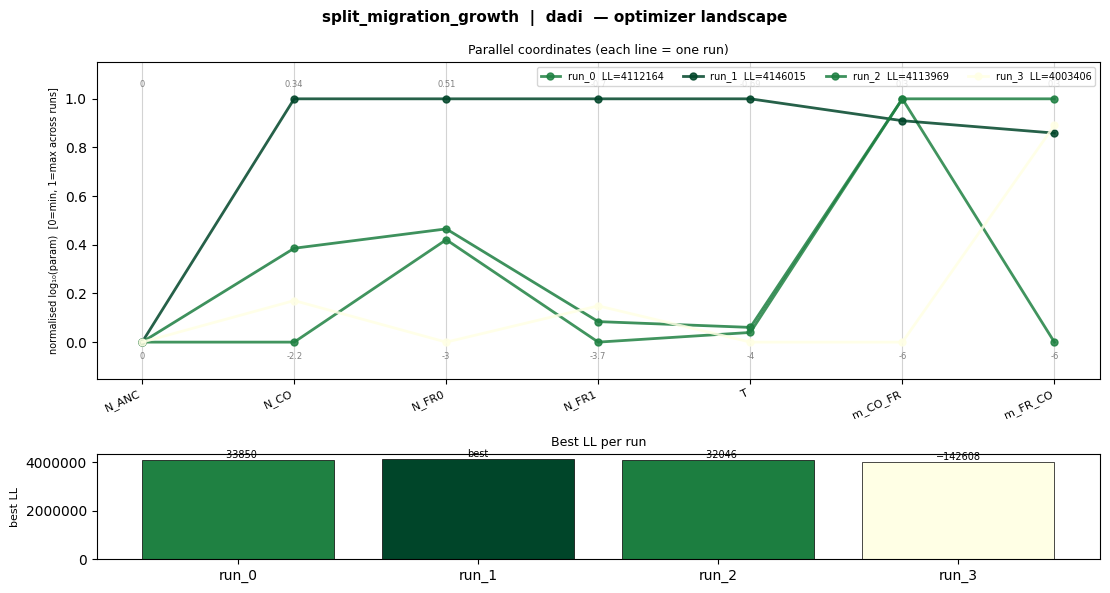

In [16]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Map model name -> correct runs root (drosophila uses _prior subdirectory)
RUNS_ROOT = {
    "drosophila_three_epoch": f"{BASE}/drosophila_three_epoch_prior/real_data_analysis/runs",
    "split_migration_growth": f"{BASE}/split_migration_growth/real_data_analysis/runs",
}

for model in MODELS:
    params = PARAMS_BY_MODEL[model]
    for engine in SFS_ENGINES:
        runs_root = RUNS_ROOT[model]
        run_dirs  = sorted(glob.glob(f"{runs_root}/run_*"))
        if not run_dirs:
            print(f"{model} / {engine}: no run dirs found")
            continue

        # --- collect per-run MLE and best LL from profile argmax ---
        run_records = []
        for run_dir in run_dirs:
            run_name = run_dir.split("/")[-1]
            mle = {}
            best_ll = None
            for param in params:
                npz = f"{run_dir}/inferences/{engine}/likelihood_plots_scaled/profile_{param}.npz"
                try:
                    d = np.load(npz)
                except FileNotFoundError:
                    continue
                ll_arr = d["ll"]
                idx = np.argmax(ll_arr)
                mle[param] = 10 ** d["grid_log10"][idx]
                # best LL = the profile's own maximum (the run's objective value)
                if best_ll is None or ll_arr[idx] > best_ll:
                    best_ll = float(ll_arr[idx])
            if mle:
                run_records.append({"run": run_name, "mle": mle, "best_ll": best_ll})

        if not run_records:
            continue

        n_runs  = len(run_records)
        best_lls = np.array([r["best_ll"] for r in run_records])

        # colour by LL (higher = darker green)
        norm   = mcolors.Normalize(vmin=best_lls.min(), vmax=best_lls.max())
        cmap   = cm.get_cmap("YlGn")
        colors_run = [cmap(norm(ll)) for ll in best_lls]

        # --- parallel coordinates ---
        fig, (ax_par, ax_bar) = plt.subplots(
            2, 1, figsize=(len(params) * 1.6, 6),
            gridspec_kw={"height_ratios": [3, 1]}
        )
        fig.suptitle(f"{model}  |  {engine}  — optimizer landscape", fontsize=11, fontweight="bold")

        x_pos = np.arange(len(params))

        # normalise each parameter to [0,1] across runs for the parallel-coords y axis
        param_vals = np.array([
            [np.log10(r["mle"].get(p, np.nan)) for p in params]
            for r in run_records
        ])  # shape (n_runs, n_params), in log10 space

        col_min = np.nanmin(param_vals, axis=0)
        col_max = np.nanmax(param_vals, axis=0)
        col_range = col_max - col_min
        col_range[col_range == 0] = 1  # avoid divide-by-zero for locked params

        param_norm = (param_vals - col_min) / col_range  # [0,1] per column

        for ri, (record, color) in enumerate(zip(run_records, colors_run)):
            y = param_norm[ri]
            mask = ~np.isnan(y)
            ax_par.plot(x_pos[mask], y[mask],
                        color=color, lw=2, alpha=0.85,
                        marker="o", markersize=5,
                        label=f"{record['run']}  LL={record['best_ll']:.0f}")

        # annotate actual log10 values at top/bottom of each axis
        for j, param in enumerate(params):
            ax_par.text(j, 1.04, f"{col_max[j]:.2g}", ha="center", va="bottom",
                        fontsize=6, color="gray")
            ax_par.text(j, -0.04, f"{col_min[j]:.2g}", ha="center", va="top",
                        fontsize=6, color="gray")
            ax_par.axvline(j, color="lightgray", lw=0.8, zorder=0)

        ax_par.set_xticks(x_pos)
        ax_par.set_xticklabels(params, rotation=25, ha="right", fontsize=8)
        ax_par.set_ylabel("normalised log₁₀(param)  [0=min, 1=max across runs]", fontsize=7)
        ax_par.set_ylim(-0.15, 1.15)
        ax_par.legend(fontsize=7, loc="upper right", ncol=n_runs)
        ax_par.set_title("Parallel coordinates (each line = one run)", fontsize=9)

        # --- LL bar chart ---
        run_labels = [r["run"] for r in run_records]
        bars = ax_bar.bar(run_labels, best_lls, color=colors_run, edgecolor="k", lw=0.5)
        ax_bar.set_ylabel("best LL", fontsize=8)
        ax_bar.set_title("Best LL per run", fontsize=9)
        ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}"))
        # annotate ΔLL from the best run
        top_ll = best_lls.max()
        for bar, ll_val in zip(bars, best_lls):
            delta = top_ll - ll_val
            label = "best" if delta == 0 else f"−{delta:.0f}"
            ax_bar.text(bar.get_x() + bar.get_width() / 2, ll_val,
                        label, ha="center", va="bottom", fontsize=7)

        plt.tight_layout()
        plt.show()